#  Gamma/neutron discrimination based on ML

- Workflow based on R. S. Molina, I. R. Morales, M. L. Crespo, V. G. Costa, S. Carrato and G. Ramponi, "An End-to-End Workflow to Efficiently Compress and Deploy DNN Classifiers on SoC/FPGA", in IEEE Embedded Systems Letters, vol. 16, no. 3, pp. 255-258, Sept. 2024, doi: 10.1109/LES.2023.3343030.

- Code adapted from the official repository of  "An End-to-End Workflow to Efficiently Compress and Deploy DNN Classifiers on SoC/FPGA"

- Using open dataset from: https://doi.org/10.5281/zenodo.8037058


### Importacion de librerias

In [2]:
#MLab UDMA library
import udma 

import matplotlib.pyplot as plt
from time import sleep

In [3]:
import numpy as np

In [4]:
# Length of the input signal 
TRACE_LEN = 161

# Input registers
CB_INFERENCE_REG = 2 # Inference result
CB_FIFO_REG = 3 # Inference result
CB_LEDS_REG = 4

### PYNQ Connection

In [5]:
#IP_ADDRESS = 'XXX.XXX.XXX.XXX' # Set your ZedBoard IP Address here
IP_ADDRESS = '192.168.1.10' 
IP_PORT = 7 

In [6]:
pynq = udma.UDMA_CLASS(IP_ADDRESS, IP_PORT)

In [7]:
connectionStatus = 0
while(connectionStatus == 0):
    connectionStatus = pynq.connect()
    sleep(1)

In [8]:
pynq.log(0)

[(5,), 0]

In [9]:
 # Function definition: used to clear out FIFO contents prior to read any value
def clearInFifo(udmaInstance):
    CB_CLEAR_INFIFO = 37
    # CB_CLEAR_INFIFO = 17
    udmaInstance.write_reg(CB_CLEAR_INFIFO, 1)
    udmaInstance.write_reg(CB_CLEAR_INFIFO, 0)

In [10]:
# Gamma
# Expected value: 5
# signal = [501, 501, 501, 475, 388, 323, 269, 228, 194, 177, 168, 158, 152, 155, 158, 162, 166, 177, 186, 191, 199, 208, 218, 228, 238, 249, 254, 258, 267, 275, 283, 293, 299, 306, 313, 318, 323, 331, 334, 341, 342, 345, 349, 355, 359, 363, 367, 373, 377, 381, 381, 384, 389, 393, 398, 401, 407, 410, 413, 416, 417, 421, 424, 426, 428, 430, 431, 436, 438, 439, 441, 442, 442, 445, 447, 447, 449, 448, 449, 451, 453, 455, 455, 457, 460, 461, 461, 461, 461, 462, 462, 462, 463, 464, 464, 465, 466, 466, 469, 469, 473, 474, 473, 474, 474, 475, 475, 474, 472, 474, 474, 475, 478, 479, 478, 480, 479, 481, 480, 482, 481, 484, 483, 484, 486, 487, 488, 487, 489, 488, 489, 489, 489, 489, 491, 492, 492, 491, 490, 492, 492, 491, 491, 493, 492, 493, 493, 494, 496, 496, 495, 498, 498, 499, 499, 498, 498, 499, 498, 499, 499]

signal = [403, 403, 404, 389, 379, 370, 365, 359, 356, 353, 353, 355, 355, 354, 357, 357, 360, 362, 362, 363, 366, 366, 366, 364, 365, 367, 369, 371, 372, 374, 375, 375, 377, 378, 379, 380, 381, 379, 380, 380, 382, 382, 384, 385, 383, 384, 384, 385, 386, 384, 387, 389, 389, 389, 389, 391, 392, 391, 391, 389, 391, 391, 390, 391, 392, 391, 394, 394, 394, 394, 394, 394, 396, 396, 396, 397, 398, 397, 397, 396, 398, 395, 396, 394, 396, 396, 398, 397, 398, 397, 399, 398, 399, 399, 399, 400, 399, 400, 400, 400, 398, 397, 399, 398, 398, 397, 397, 397, 399, 399, 398, 400, 400, 401, 400, 400, 400, 400, 401, 402, 402, 402, 402, 401, 402, 401, 401, 402, 401, 401, 400, 400, 400, 400, 400, 401, 401, 401, 402, 401, 401, 401, 402, 402, 402, 402, 403, 401, 401, 402, 401, 401, 401, 401, 401, 402, 401, 403, 402, 401, 403]


# Neutron
# Expected value: 3
#signal = [404,405,404,405,404,404,405,405,405,404,405,403,404,404,404,404,402,400,397,394,392,386,381,376,371,365,359,354,349,343,337,331,324,318,312,305,298,295,286,283,276,273,268,263,259,255,249,243,240,236,232,227,225,220,218,214,211,208,204,202,198,194,191,188,185,181,179,176,173,171,167,165,163,158,158,154,152,149,146,144,141,141,137,136,132,132,129,127,125,123,121,119,119,116,114,112,111,109,108,105,104,103,102,100,98,96,95,93,92,90,89,88,87,86,84,83,81,81,79,79,76,76,75,74,72,72,71,69,69,69,69,68,69,67,68,66,66,65,65,65,64,66,64,64,64,64,64,63,63,64,62,62,61,61,60,60,59,59,59,58,59]


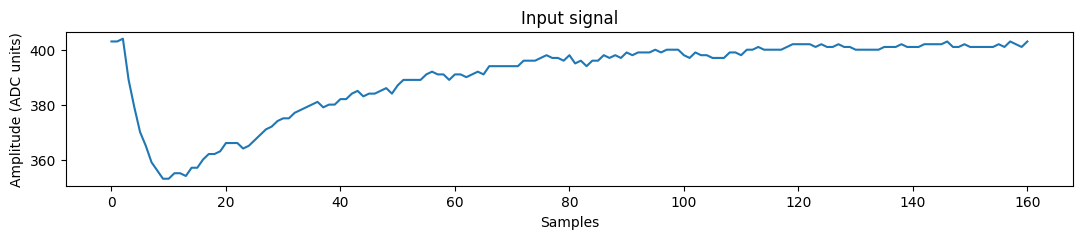

In [11]:
fig = plt.figure(figsize=(13,2))
plt.plot(signal)
plt.title("Input signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude (ADC units)")
plt.show()

### Interaction with ComBlock to send the signal and receive the inference result

In [12]:
# Clear input FIFO contents to get the latest data from the FIR filter output
clearInFifo(pynq)

In [13]:
# Initialize HLS IP core
pynq.write_reg(reg=1, data=0)
pynq.write_reg(reg=1, data=1)

[(1, 0), 0]

In [14]:
# Initialize HLS IP core
pynq.write_reg(reg=CB_LEDS_REG, data=4)

[(1, 0), 0]

In [15]:
# Initialize HLS IP core
pynq.write_reg(reg=CB_FIFO_REG, data=0)

[(1, 0), 0]

In [16]:
# Writing to ComBlock the signal to be used as input for the inference IP core
# signal should be array-type

pynq.write_fifo(length=len(signal), Txdata=signal)#[0] # <--- This is the signal variable that will be sent
pynq.write_reg(reg=2, data=1)
pynq.write_reg(reg=2, data=0)

[(1, 0), 0]

### Inference result

In [17]:
 # Read inference result
pynq.read_reg(reg=CB_INFERENCE_REG)[1][0]

3

[403, 403, 404, 389, 379, 370, 365, 359, 356, 353, 353, 355, 355, 354, 357, 357, 360, 362, 362, 363, 366, 366, 366, 364, 365, 367, 369, 371, 372, 374, 375, 375, 377, 378, 379, 380, 381, 379, 380, 380, 382, 382, 384, 385, 383, 384, 384, 385, 386, 384, 387, 389, 389, 389, 389, 391, 392, 391, 391, 389, 391, 391, 390, 391, 392, 391, 394, 394, 394, 394, 394, 394, 396, 396, 396, 397, 398, 397, 397, 396, 398, 395, 396, 394, 396, 396, 398, 397, 398, 397, 399, 398, 399, 399, 399, 400, 399, 400, 400, 400, 398, 397, 399, 398, 398, 397, 397, 397, 399, 399, 398, 400, 400, 401, 400, 400, 400, 400, 401, 402, 402, 402, 402, 401, 402, 401, 401, 402, 401, 401, 400, 400, 400, 400, 400, 401, 401, 401, 402, 401, 401, 401, 402, 402, 402, 402, 403, 401, 401, 402, 401, 401, 401, 401, 401, 402, 401, 403, 402, 401, 403]
161
0


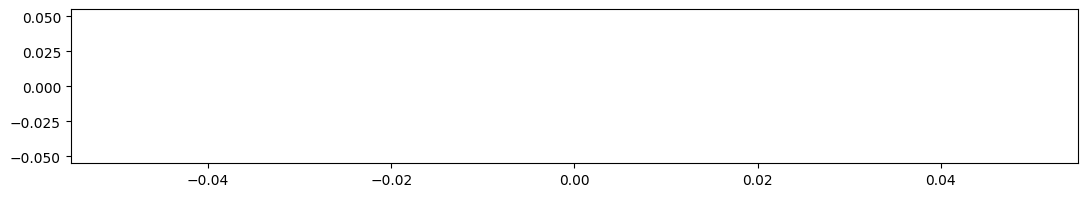

In [18]:
test = pynq.read_fifo(len(signal))[1]

plt.figure(figsize=(13,2))
plt.plot(test)
print(signal)
print(len(signal))
print(test)

# Evaluacion de datos de test

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import shuffle

import pandas as pd

In [20]:
# Cargar el archivo test.csv
df = pd.read_csv('../dataset/test_udma_dataset.csv')
#df = shuffle(df)

# Separar señales y etiquetas
X_signals = df.drop('class', axis=1)   # Todas las columnas menos 'class'
y_labels = df['class']                 # Solo la columna 'class'

# Ejemplo: obtener la primera señal y su etiqueta
signal = X_signals.iloc[0].values.tolist()      # Señal como array
label = y_labels.iloc[0]                        # Etiqueta

print("Primera señal:", signal)
print("Etiqueta:", label)

Primera señal: [403, 403, 403, 391, 379, 375, 373, 371, 368, 366, 364, 363, 364, 365, 364, 365, 365, 367, 368, 371, 370, 371, 371, 373, 373, 375, 377, 376, 378, 380, 380, 382, 383, 385, 385, 385, 385, 386, 386, 388, 387, 388, 388, 389, 389, 390, 389, 389, 390, 392, 391, 391, 392, 393, 392, 392, 392, 393, 393, 394, 393, 395, 394, 394, 395, 395, 395, 395, 395, 395, 395, 397, 396, 396, 397, 396, 396, 396, 397, 397, 396, 397, 398, 398, 399, 398, 397, 399, 400, 399, 400, 399, 399, 398, 399, 400, 399, 400, 399, 397, 398, 399, 399, 400, 399, 400, 400, 401, 400, 402, 401, 401, 401, 400, 399, 400, 399, 399, 400, 401, 399, 400, 400, 401, 400, 399, 399, 399, 400, 401, 401, 401, 401, 400, 400, 402, 402, 402, 402, 400, 401, 400, 400, 401, 401, 400, 401, 401, 400, 401, 400, 402, 402, 402, 401, 402, 402, 401, 402, 402, 402]
Etiqueta: 0


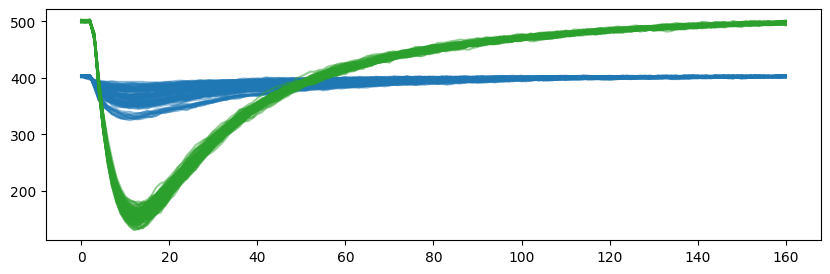

In [21]:
plt.figure(figsize=(10,3))

for i in range(0,len(X_signals)):
    if y_labels.iloc[i] == 0: # Gamma
        plt.plot(X_signals.iloc[i].values.tolist(), color='tab:blue', alpha=0.5, label='Gamma' if i == 0 else "")
        #plt.fill_between(X_signals.iloc[i].values.tolist(), X_signals.iloc[i].values.tolist()-10, color='tab:gray', alpha=0.05)  # Sombra pequeña
    elif y_labels.iloc[i] == 1: # Neutron
        plt.plot(X_signals.iloc[i].values.tolist(), color='tab:green', alpha=0.5, label='Neutron' if i == 0 else "")
        #plt.fill_between(X_signals.iloc[i].values.tolist(), X_signals.iloc[i].values.tolist()-10, color='tab:gray', alpha=0.05)  # Sombra pequeña

In [22]:
predic = []
specte = []

for i in range(0,len(X_signals)):

    signal = X_signals.iloc[i].values.tolist()      # Señal como array
    specte.append(y_labels.iloc[i])

    pynq.write_fifo(length=len(signal), Txdata=signal)[0] # <--- This is the signal variable that will be sent
    pynq.write_reg(reg=2, data=1)
    pynq.write_reg(reg=2, data=0)

    result = pynq.read_reg(reg=CB_INFERENCE_REG)[1][0]
    if result == 3:
        predic.append(0)
    elif result == 5:
        predic.append(1)
    else:
        predic.append(2)



In [23]:
print(predic)
print(specte)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

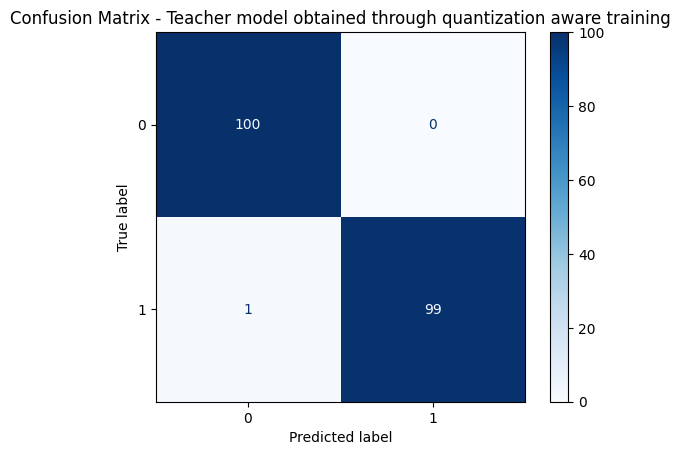

In [24]:
cm = confusion_matrix(specte, predic)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title('Confusion Matrix - Teacher model obtained through quantization aware training')
plt.show()

### Dataset de prueba

In [37]:
# Cargar el archivo test.csv
dfg = pd.read_csv('../dataset/train_gamma_dataset.csv')
dfg = shuffle(dfg.iloc[:500])
dfn = pd.read_csv('../dataset/train_neutron_dataset.csv')
dfn = shuffle(dfn.iloc[:500])


# Separar señales y etiquetas
Xn_signals = dfn.drop('class', axis=1)   # Todas las columnas menos 'class'
Xg_signals = dfg.drop('class', axis=1)   # Todas las columnas menos 'class'
yn_labels = dfn['class']                 # Solo la columna 'class'
yg_labels = dfg['class']                 # Solo la columna 'class'

X_signals = pd.concat([Xn_signals, Xg_signals])
y_labels = pd.concat([yn_labels, yg_labels])

# Ejemplo: obtener la primera señal y su etiqueta
signal = X_signals.iloc[0].values.tolist()      # Señal como array
label = y_labels.iloc[0]                        # Etiqueta

print("Primera señal:", signal)
print("Etiqueta:", label)

Primera señal: [505, 504, 504, 466, 370, 303, 252, 204, 180, 157, 145, 136, 135, 139, 144, 151, 160, 168, 178, 183, 190, 201, 213, 221, 230, 239, 247, 254, 257, 271, 282, 286, 294, 300, 310, 319, 325, 329, 333, 340, 347, 350, 356, 362, 368, 372, 377, 380, 384, 388, 394, 400, 399, 401, 404, 408, 409, 409, 412, 414, 418, 419, 423, 427, 428, 430, 431, 432, 436, 439, 438, 439, 441, 443, 446, 449, 450, 451, 450, 452, 452, 454, 454, 455, 458, 461, 463, 464, 466, 468, 469, 468, 468, 469, 469, 471, 471, 471, 474, 474, 474, 474, 477, 477, 478, 480, 479, 481, 482, 482, 483, 482, 483, 483, 483, 484, 485, 486, 487, 489, 490, 490, 490, 491, 493, 492, 491, 493, 494, 493, 492, 492, 493, 495, 494, 494, 494, 492, 496, 496, 496, 497, 496, 498, 498, 499, 500, 498, 498, 497, 499, 499, 499, 499, 499, 500, 501, 501, 501, 502, 502]
Etiqueta: 1


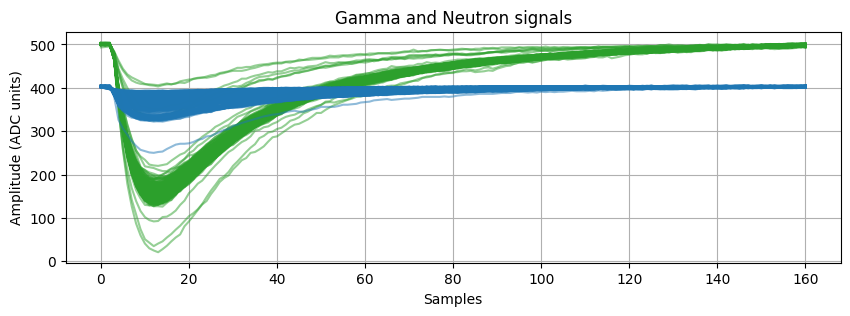

In [45]:
plt.figure(figsize=(10,3))

for i in range(0,1000):
    if y_labels.iloc[i] == 0: # Gamma
        plt.plot(X_signals.iloc[i].values.tolist(), color='tab:blue', alpha=0.5, label='Gamma' if i == 0 else "")
        # plt.fill_between(X_signals.iloc[i].values.tolist(), X_signals.iloc[i].values.tolist()-10, color='tab:gray', alpha=0.05)  # Sombra pequeña
    elif y_labels.iloc[i] == 1: # Neutron
        plt.plot(X_signals.iloc[i].values.tolist(), color='tab:green', alpha=0.5, label='Neutron' if i == 0 else "")
        # plt.fill_between(X_signals.iloc[i].values.tolist(), X_signals.iloc[i].values.tolist()-10, color='tab:gray', alpha=0.05)  # Sombra pequeña

plt.grid()
plt.title('Gamma and Neutron signals')
plt.xlabel('Samples')
plt.ylabel('Amplitude (ADC units)')
plt.show()

In [40]:
predic = []
specte = []

for i in range(0,1000):

    signal = X_signals.iloc[i].values.tolist()      # Señal como array
    specte.append(y_labels.iloc[i])

    pynq.write_fifo(length=len(signal), Txdata=signal)[0] # <--- This is the signal variable that will be sent
    pynq.write_reg(reg=2, data=1)
    pynq.write_reg(reg=2, data=0)

    result = pynq.read_reg(reg=CB_INFERENCE_REG)[1][0]
    if result == 3:
        predic.append(0)
    elif result == 5:
        predic.append(1)
    else:
        predic.append(2)

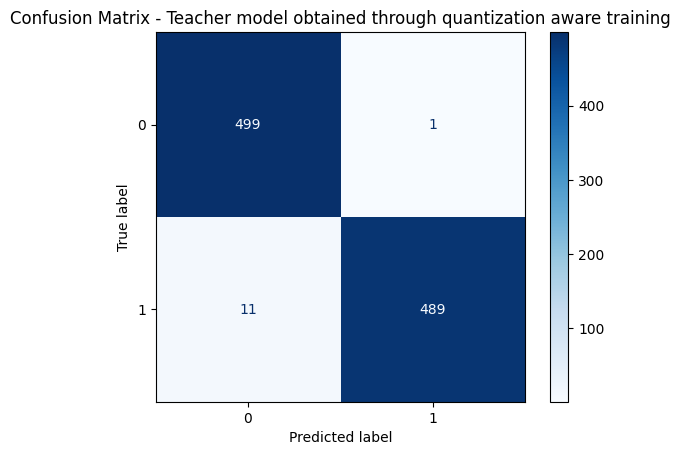

In [46]:
cm = confusion_matrix(specte, predic)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title('Confusion Matrix - Teacher model obtained through quantization aware training')
plt.show()